# Kernel Approximations: Nystrom & Random Fourier Features

Full kernel matrices cost $O(N^2)$ memory and $O(N^3)$ time to
factorize. For large-scale GP inference we need structured
approximations that preserve the low-rank nature of the kernel.

This notebook showcases six gaussx utilities:

| Function | Returns | Purpose |
|----------|---------|---------|
| `nystrom_operator` | `LowRankUpdate` | Nystrom low-rank approximation |
| `rff_operator` | `LowRankUpdate` | Random Fourier features approximation |
| `center_kernel` | `MatrixLinearOperator` | Center a kernel matrix ($HKH$) |
| `centering_operator` | `LowRankUpdate` | Centering matrix $H = I - 11^T/n$ |
| `hsic` | scalar | Hilbert-Schmidt Independence Criterion |
| `mmd_squared` | scalar | Maximum Mean Discrepancy (squared) |

## Background

**Nystrom approximation.** Given $N$ data points and $M \ll N$ inducing
(landmark) points $Z$, the Nystrom method approximates the full kernel
matrix as

$$K_{ff} \approx Q_{ff} = K_{fM} K_{MM}^{-1} K_{Mf}$$

This is a rank-$M$ positive semi-definite matrix. Internally, gaussx
stores it as a `LowRankUpdate` with zero base and factor
$U = K_{fM} L_{MM}^{-\top}$ where $L_{MM}$ is the Cholesky factor of
$K_{MM}$, so that $Q_{ff} = U U^\top$. Adding noise gives
$Q_{ff} + \sigma^2 I$, a `LowRankUpdate` that can be solved in
$O(NM^2)$ via the Woodbury identity.

**Random Fourier Features (RFF).** Rahimi & Recht (2007) showed that
for shift-invariant kernels the kernel function can be approximated via
a finite-dimensional random feature map:

$$k(x, x') \approx \phi(x)^\top \phi(x'), \quad
  \phi_j(x) = \sqrt{\frac{2}{D}} \cos(\omega_j^\top x + b_j)$$

where $\omega_j$ is drawn from the spectral density of the kernel and
$b_j \sim \mathrm{Uniform}(0, 2\pi)$. For the RBF kernel with
lengthscale $\ell$, the spectral density is
$\omega \sim \mathcal{N}(0, \ell^{-2} I)$.
The feature matrix $\Phi \in \mathbb{R}^{N \times D}$ gives a rank-$D$
approximation $K \approx \Phi \Phi^\top$, again stored as a
`LowRankUpdate`.

In [1]:
from __future__ import annotations

import warnings


warnings.filterwarnings("ignore", message=r".*IProgress.*")

import jax
import jax.numpy as jnp
import lineax as lx
import matplotlib.pyplot as plt

import gaussx


jax.config.update("jax_enable_x64", True)

## Setup: 1D GP regression data

We generate 500 noisy observations from a smooth function and define
an RBF kernel helper.

In [2]:
key = jax.random.PRNGKey(42)
k1, k2 = jax.random.split(key)

n_train = 500
noise_std = 0.2

f_true = lambda x: jnp.sin(3 * x) * jnp.exp(-0.5 * x**2)

x_train = jnp.sort(jax.random.uniform(k1, (n_train,), minval=-4.0, maxval=4.0))
y_train = f_true(x_train) + noise_std * jax.random.normal(k2, (n_train,))

x_plot = jnp.linspace(-4.5, 4.5, 300)

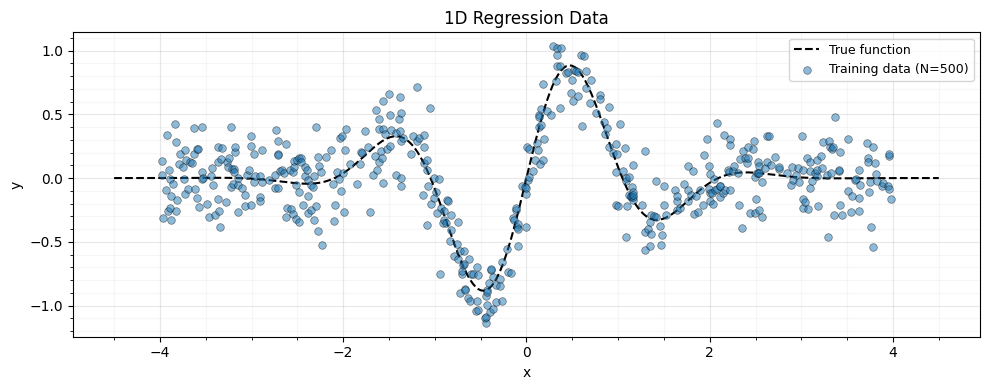

In [3]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(x_plot, f_true(x_plot), "k--", lw=1.5, label="True function", zorder=4)
ax.scatter(
    x_train,
    y_train,
    s=30,
    c="C0",
    edgecolors="k",
    linewidths=0.5,
    alpha=0.5,
    label="Training data (N=500)",
    zorder=5,
)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend(fontsize=9)
ax.set_title("1D Regression Data")
ax.grid(True, which="major", alpha=0.3)
ax.grid(True, which="minor", alpha=0.1)
ax.minorticks_on()
plt.tight_layout()
plt.show()

### RBF kernel helper

In [4]:
def rbf_kernel(x1, x2, lengthscale, variance):
    """Squared-exponential kernel matrix."""
    sq_dist = (x1[:, None] - x2[None, :]) ** 2
    return variance * jnp.exp(-0.5 * sq_dist / lengthscale**2)


lengthscale = 0.8
variance = 1.0
noise_var = noise_std**2

# Full kernel matrix for comparison
K_full = rbf_kernel(x_train, x_train, lengthscale, variance)
K_full_op = lx.MatrixLinearOperator(K_full)

## 3. Nystrom Approximation

We select $M$ inducing points on an evenly-spaced grid and build the
Nystrom low-rank approximation.

In [5]:
m_inducing = 30
z_inducing = jnp.linspace(-4.0, 4.0, m_inducing)

# Cross-covariance K_XZ (N, M) and inducing kernel K_ZZ (M, M)
K_XZ = rbf_kernel(x_train, z_inducing, lengthscale, variance)
K_ZZ = rbf_kernel(z_inducing, z_inducing, lengthscale, variance)
K_ZZ_op = lx.MatrixLinearOperator(K_ZZ)

# Build the Nystrom operator -> LowRankUpdate
K_nys = gaussx.nystrom_operator(K_XZ, K_ZZ_op)
print(f"Nystrom operator type: {type(K_nys).__name__}")

Nystrom operator type: LowRankUpdate


### Approximation quality

Compare the Nystrom approximation against the full kernel via the
Frobenius norm error and a diagonal comparison.

In [6]:
K_nys_dense = K_nys.as_matrix()
frob_error = jnp.linalg.norm(K_full - K_nys_dense, "fro")
frob_relative = frob_error / jnp.linalg.norm(K_full, "fro")

print(f"Frobenius norm error:    {frob_error:.4f}")
print(f"Relative Frobenius err:  {frob_relative:.4f}")

Frobenius norm error:    0.0000
Relative Frobenius err:  0.0000


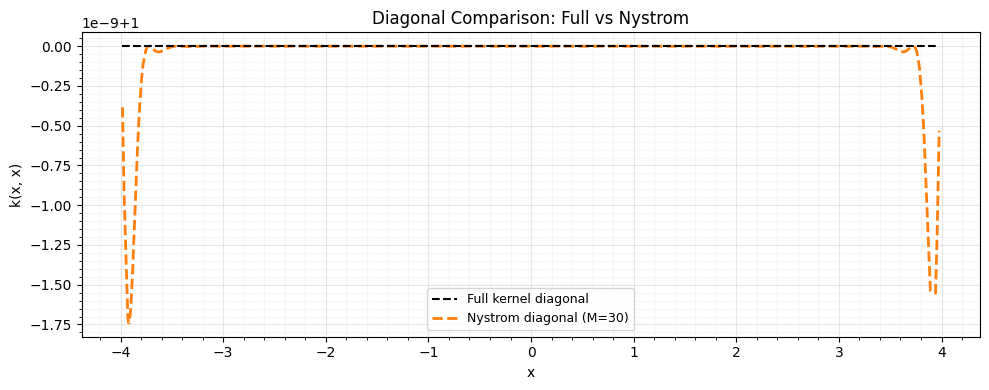

In [7]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(
    x_train,
    jnp.diag(K_full),
    "k--",
    lw=1.5,
    label="Full kernel diagonal",
    zorder=4,
)
ax.plot(
    x_train,
    jnp.diag(K_nys_dense),
    "--",
    color="C1",
    lw=2,
    label=f"Nystrom diagonal (M={m_inducing})",
    zorder=3,
)
ax.set_xlabel("x")
ax.set_ylabel("k(x, x)")
ax.legend(fontsize=9)
ax.set_title("Diagonal Comparison: Full vs Nystrom")
ax.grid(True, which="major", alpha=0.3)
ax.grid(True, which="minor", alpha=0.1)
ax.minorticks_on()
plt.tight_layout()
plt.show()

### GP regression with the Nystrom approximation

The system to solve is $(K_{\mathrm{nys}} + \sigma^2 I) \alpha = y$.
Because $K_{\mathrm{nys}}$ is a `LowRankUpdate`, gaussx exploits the
Woodbury identity automatically, giving $O(NM^2)$ cost instead of
$O(N^3)$.

In [8]:
# Build K_nys + sigma^2 I as a LowRankUpdate with diagonal base
K_noisy = gaussx.LowRankUpdate(
    base=lx.DiagonalLinearOperator(jnp.full(n_train, noise_var)),
    U=K_nys.U,
    d=K_nys.d,
    V=K_nys.V,
)

alpha_nys = gaussx.solve(K_noisy, y_train)

# Predictions at test points
K_star_Z = rbf_kernel(x_plot, z_inducing, lengthscale, variance)
K_star_train = rbf_kernel(x_plot, x_train, lengthscale, variance)
mu_nys = K_star_train @ alpha_nys

# Full GP for reference
K_noisy_full = lx.MatrixLinearOperator(K_full + noise_var * jnp.eye(n_train))
alpha_full = gaussx.solve(K_noisy_full, y_train)
mu_full = K_star_train @ alpha_full

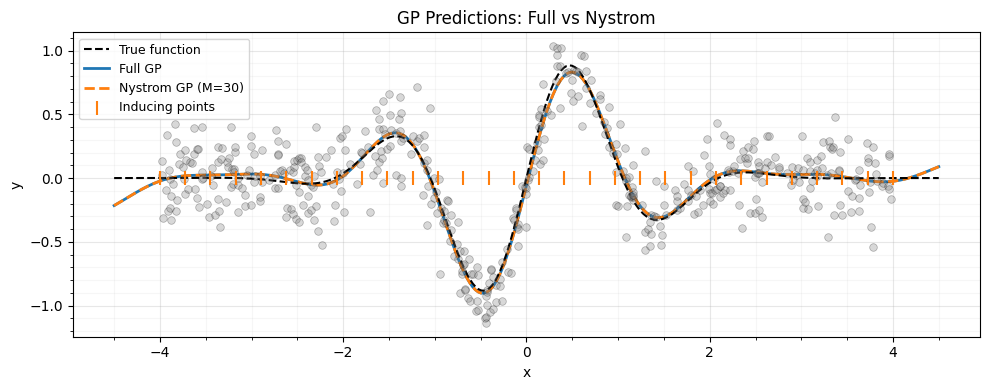

In [9]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(x_plot, f_true(x_plot), "k--", lw=1.5, label="True function", zorder=4)
ax.plot(x_plot, mu_full, "C0-", lw=2, label="Full GP", zorder=3)
ax.plot(x_plot, mu_nys, "C1--", lw=2, label=f"Nystrom GP (M={m_inducing})", zorder=3)
ax.scatter(
    x_train,
    y_train,
    s=30,
    c="grey",
    edgecolors="k",
    linewidths=0.5,
    alpha=0.3,
    zorder=5,
)
ax.scatter(
    z_inducing,
    jnp.zeros_like(z_inducing),
    marker="|",
    s=100,
    c="C1",
    zorder=5,
    label="Inducing points",
)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend(fontsize=9)
ax.set_title("GP Predictions: Full vs Nystrom")
ax.grid(True, which="major", alpha=0.3)
ax.grid(True, which="minor", alpha=0.1)
ax.minorticks_on()
plt.tight_layout()
plt.show()

## 4. Random Fourier Features

For the RBF kernel with lengthscale $\ell$, we sample
$\omega \sim \mathcal{N}(0, \ell^{-2} I)$ and
$b \sim \mathrm{Uniform}(0, 2\pi)$.

In [10]:
k_rff = jax.random.PRNGKey(99)
D_rff = 500

k_omega, k_b = jax.random.split(k_rff)
omega = jax.random.normal(k_omega, (D_rff, 1)) / lengthscale  # (D_rff, D=1)
b = jax.random.uniform(k_b, (D_rff,), minval=0.0, maxval=2.0 * jnp.pi)

# X must be (N, D) -- reshape 1D inputs
X_2d = x_train[:, None]  # (N, 1)

K_rff = gaussx.rff_operator(X_2d, omega, b)
print(f"RFF operator type: {type(K_rff).__name__}")

RFF operator type: LowRankUpdate


In [11]:
K_rff_dense = K_rff.as_matrix()
frob_rff = jnp.linalg.norm(K_full - K_rff_dense, "fro")
frob_rff_rel = frob_rff / jnp.linalg.norm(K_full, "fro")

print(f"RFF Frobenius error (D={D_rff}): {frob_rff:.4f}")
print(f"RFF relative error:              {frob_rff_rel:.4f}")

RFF Frobenius error (D=500): 24.3464
RFF relative error:              0.1189


### Convergence with increasing feature dimension

As $D_{\mathrm{rff}}$ grows the approximation improves at
$O(1 / \sqrt{D})$ rate.

In [12]:
D_values = [100, 500, 1000]
errors = []

for D in D_values:
    k_o, k_bb = jax.random.split(jax.random.PRNGKey(D))
    om = jax.random.normal(k_o, (D, 1)) / lengthscale
    bb = jax.random.uniform(k_bb, (D,), minval=0.0, maxval=2.0 * jnp.pi)
    K_approx = gaussx.rff_operator(X_2d, om, bb).as_matrix()
    err = jnp.linalg.norm(K_full - K_approx, "fro") / jnp.linalg.norm(K_full, "fro")
    errors.append(float(err))
    print(f"  D_rff = {D:5d}  |  relative error = {err:.4f}")

  D_rff =   100  |  relative error = 0.3016
  D_rff =   500  |  relative error = 0.0947


  D_rff =  1000  |  relative error = 0.0488


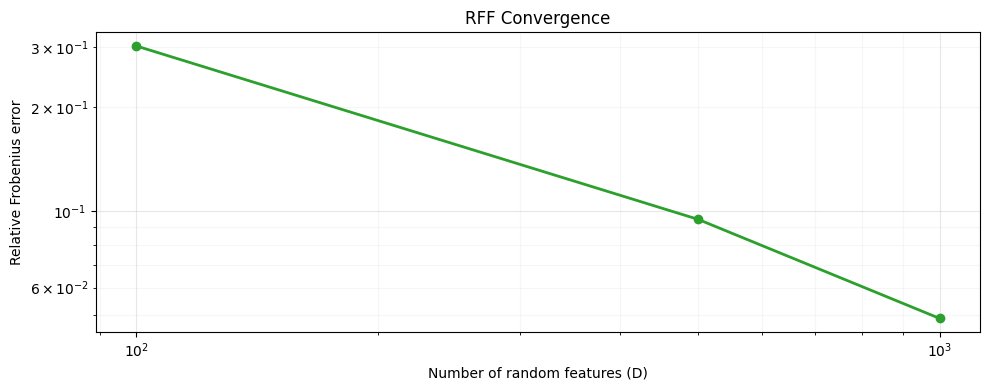

In [13]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.loglog(D_values, errors, "o-", color="C2", lw=2)
ax.set_xlabel("Number of random features (D)")
ax.set_ylabel("Relative Frobenius error")
ax.set_title("RFF Convergence")
ax.grid(True, which="major", alpha=0.3)
ax.grid(True, which="minor", alpha=0.1)
ax.minorticks_on()
plt.tight_layout()
plt.show()

## 5. Kernel Centering

Centering a kernel matrix is required for kernel PCA and many kernel
methods. The centered kernel is $\tilde{K} = H K H$ where
$H = I - \frac{1}{n}\mathbf{1}\mathbf{1}^\top$ is the centering matrix.

In [14]:
n = n_train

# Build the centering operator H = I - (1/n) 11^T
H_op = gaussx.centering_operator(n)
print(f"Centering operator type: {type(H_op).__name__}")

H_dense = H_op.as_matrix()
print(f"H shape: {H_dense.shape}")

# Verify it is I - (1/n) 11^T
H_manual = jnp.eye(n) - jnp.ones((n, n)) / n
print(f"H matches manual: {jnp.allclose(H_dense, H_manual, atol=1e-12)}")

Centering operator type: LowRankUpdate
H shape: (500, 500)


H matches manual: True


### Center the kernel matrix

In [15]:
K_centered_op = gaussx.center_kernel(K_full_op)
K_centered = K_centered_op.as_matrix()

# Manual centering: HKH
K_centered_manual = H_manual @ K_full @ H_manual

print(f"Centered kernel type: {type(K_centered_op).__name__}")
print(f"Matches manual HKH:  {jnp.allclose(K_centered, K_centered_manual, atol=1e-10)}")
print(f"Centered row sums ~ 0: {jnp.abs(K_centered.sum(axis=1)).max():.2e}")

Centered kernel type: MatrixLinearOperator
Matches manual HKH:  True
Centered row sums ~ 0: 8.26e-14


## 6. HSIC: Independence Testing

The Hilbert-Schmidt Independence Criterion measures dependence between
two random variables via their kernel embeddings:

$$\mathrm{HSIC}(F, G) = \frac{1}{n^2} \operatorname{tr}(K_f H K_g H)$$

HSIC $= 0$ if and only if $F$ and $G$ are independent (in the
population, with characteristic kernels). We compare a correlated
pair $(x, y = x + \epsilon)$ with an independent pair $(x, z)$.

In [16]:
key_hsic = jax.random.PRNGKey(7)
k1, k2, k3 = jax.random.split(key_hsic, 3)

n_hsic = 200
x_hsic = jax.random.normal(k1, (n_hsic,))

# Correlated pair: y depends on x
y_corr = x_hsic + 0.3 * jax.random.normal(k2, (n_hsic,))

# Independent pair: z is independent of x
z_indep = jax.random.normal(k3, (n_hsic,))

# Build kernel matrices (RBF, lengthscale=1)
K_x = rbf_kernel(x_hsic, x_hsic, 1.0, 1.0)
K_y_corr = rbf_kernel(y_corr, y_corr, 1.0, 1.0)
K_z_indep = rbf_kernel(z_indep, z_indep, 1.0, 1.0)

K_x_op = lx.MatrixLinearOperator(K_x)
K_y_op = lx.MatrixLinearOperator(K_y_corr)
K_z_op = lx.MatrixLinearOperator(K_z_indep)

In [17]:
hsic_corr = gaussx.hsic(K_x_op, K_y_op)
hsic_indep = gaussx.hsic(K_x_op, K_z_op)

print(f"HSIC (x, y_correlated):  {hsic_corr:.6f}   (should be > 0)")
print(f"HSIC (x, z_independent): {hsic_indep:.6f}   (should be ~ 0)")

HSIC (x, y_correlated):  0.055927   (should be > 0)
HSIC (x, z_independent): 0.002026   (should be ~ 0)


## 7. MMD: Two-Sample Testing

The Maximum Mean Discrepancy measures the distance between two
distributions in a reproducing kernel Hilbert space:

$$\mathrm{MMD}^2(P, Q) = \mathbb{E}[k(x,x')] + \mathbb{E}[k(y,y')]
  - 2\,\mathbb{E}[k(x,y)]$$

We compare $P = \mathcal{N}(0, 1)$ vs $Q = \mathcal{N}(1, 1)$
(different) and $P$ vs $P$ (same).

In [18]:
key_mmd = jax.random.PRNGKey(13)
k1, k2, k3 = jax.random.split(key_mmd, 3)

n_mmd = 200
x_p = jax.random.normal(k1, (n_mmd,))  # P = N(0, 1)
y_q = jax.random.normal(k2, (n_mmd,)) + 1.0  # Q = N(1, 1)
x_p2 = jax.random.normal(k3, (n_mmd,))  # Another sample from P

# Kernel matrices (raw arrays, not operators)
ls_mmd = 1.0
K_xx = rbf_kernel(x_p, x_p, ls_mmd, 1.0)
K_yy = rbf_kernel(y_q, y_q, ls_mmd, 1.0)
K_xy = rbf_kernel(x_p, y_q, ls_mmd, 1.0)

K_xx2 = rbf_kernel(x_p, x_p, ls_mmd, 1.0)
K_pp2 = rbf_kernel(x_p2, x_p2, ls_mmd, 1.0)
K_xp2 = rbf_kernel(x_p, x_p2, ls_mmd, 1.0)

In [19]:
mmd_diff = gaussx.mmd_squared(K_xx, K_yy, K_xy)
mmd_same = gaussx.mmd_squared(K_xx2, K_pp2, K_xp2)

print(f"MMD^2(P, Q) [different]: {mmd_diff:.6f}   (should be > 0)")
print(f"MMD^2(P, P) [same]:      {mmd_same:.6f}   (should be ~ 0)")

MMD^2(P, Q) [different]: 0.148538   (should be > 0)
MMD^2(P, P) [same]:      0.004874   (should be ~ 0)


## 8. Plots: Approximation Quality

A side-by-side comparison of the kernel matrix approximations.

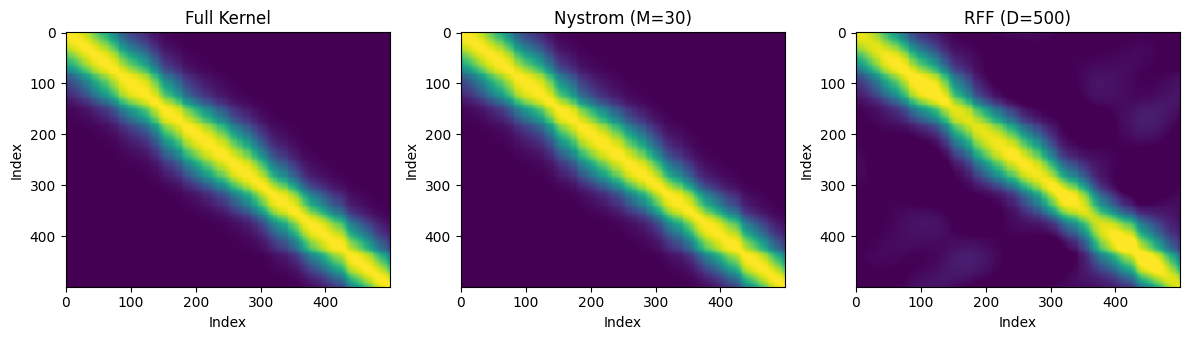

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))

vmin, vmax = K_full.min(), K_full.max()
kw = dict(vmin=vmin, vmax=vmax, cmap="viridis", aspect="auto")

axes[0].imshow(K_full, **kw)
axes[0].set_title("Full Kernel")

axes[1].imshow(K_nys_dense, **kw)
axes[1].set_title(f"Nystrom (M={m_inducing})")

axes[2].imshow(K_rff_dense, **kw)
axes[2].set_title(f"RFF (D={D_rff})")

for ax in axes:
    ax.set_xlabel("Index")
    ax.set_ylabel("Index")

plt.tight_layout()
plt.show()

## 9. Summary

| Function | Output | Cost |
|----------|--------|------|
| `nystrom_operator(K_XZ, K_ZZ_op)` | `LowRankUpdate` | $O(NM^2)$ |
| `rff_operator(X, omega, b)` | `LowRankUpdate` | $O(ND)$ |
| `center_kernel(K)` | `MatrixLinearOperator` | $O(N^2)$ |
| `centering_operator(n)` | `LowRankUpdate` | $O(1)$ |
| `hsic(K_f, K_q)` | scalar | $O(N^2)$ |
| `mmd_squared(K_xx, K_yy, K_xy)` | scalar | $O(N^2)$ |

**Key takeaways:**

- Both Nystrom and RFF produce `LowRankUpdate` operators, so
  downstream solves and log-determinants exploit the Woodbury identity
  automatically.
- `center_kernel` and `centering_operator` handle the centering
  boilerplate needed by kernel PCA and HSIC.
- `hsic` and `mmd_squared` are one-line kernel statistics for
  independence and two-sample testing.